In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

In [3]:
from marine_qc import (
    combine_qc_results,
    do_climatology_check,
    do_datetime_check,
    do_hard_limit_check,
    do_maritime_check,
    do_multiple_individual_check,
    do_position_check,
    do_valid_value_check,
    do_wind_consistency_check,
    plot_latitude_longitude,
)
from marine_qc.helpers.external_clim import get_climatological_value

In [4]:
from examples.data import get_climatology_data, get_individual_data

# How to use quality control checks with individual reports

We need some text!!!

In [5]:
data = get_individual_data()
data

,location,lat,lon,date,sea_surface_temperature,wind_speed,wind_direction
0,Mediterranean Sea,36.0,18.0,2025-06-01 06:00:00,22.8,5.2,135
1,North Sea,54.5,3.0,2025-06-01 12:00:00,13.6,0.0,270
2,South Pacific Ocean,-140.0,-15.0,2025-06-01 18:00:00,27.4,7.8,90
3,"Paris, France",48.9,2.3,2025-06-02 14:30:00,NaN,3.5,45
4,"Tokyo, Japan",35.7,139.7,2025-06-03 08:45:00,NaN,6.2,225
5,"Sydney, Australia",-33.9,151.2,2025-06-03 20:10:00,NaN,8.1,160
6,Gulf of Mexico,25.0,-90.0,NaT,29.1,10.5,315
7,Equatorial Atlantic,0.0,-30.0,2025-06-04 16:20:00,28.3,5.9,110
8,Norwegian Sea,60.0,5.0,2025-06-05 07:50:00,8.5,14.3,290


In [6]:
qc_pos = do_position_check(
    lat=data.lat,
    lon=data.lon,
)
pd.DataFrame({"location": data.location, "lat": data.lat, "lon": data.lon, "qc_pos": qc_pos})

,location,lat,lon,qc_pos
0,Mediterranean Sea,36.0,18.0,0
1,North Sea,54.5,3.0,0
2,South Pacific Ocean,-140.0,-15.0,1
3,"Paris, France",48.9,2.3,0
4,"Tokyo, Japan",35.7,139.7,0
5,"Sydney, Australia",-33.9,151.2,0
6,Gulf of Mexico,25.0,-90.0,0
7,Equatorial Atlantic,0.0,-30.0,0
8,Norwegian Sea,60.0,5.0,0


In [7]:
qc_datetime = do_datetime_check(
    data.date,
)
pd.DataFrame({"location": data.location, "date": data.date, "qc_datetime": qc_datetime})

,location,date,qc_datetime
0,Mediterranean Sea,2025-06-01 06:00:00,0
1,North Sea,2025-06-01 12:00:00,0
2,South Pacific Ocean,2025-06-01 18:00:00,0
3,"Paris, France",2025-06-02 14:30:00,0
4,"Tokyo, Japan",2025-06-03 08:45:00,0
5,"Sydney, Australia",2025-06-03 20:10:00,0
6,Gulf of Mexico,NaT,2
7,Equatorial Atlantic,2025-06-04 16:20:00,0
8,Norwegian Sea,2025-06-05 07:50:00,0


In [8]:
qc_valid = do_valid_value_check(
    data.sea_surface_temperature,
)
pd.DataFrame({"location": data.location, "sea_surface_temperature": data.sea_surface_temperature, "qc_valid": qc_valid})

,location,sea_surface_temperature,qc_valid
0,Mediterranean Sea,22.8,0
1,North Sea,13.6,0
2,South Pacific Ocean,27.4,0
3,"Paris, France",NaN,1
4,"Tokyo, Japan",NaN,1
5,"Sydney, Australia",NaN,1
6,Gulf of Mexico,29.1,0
7,Equatorial Atlantic,28.3,0
8,Norwegian Sea,8.5,0


In [9]:
qc_hard = do_hard_limit_check(
    data.sea_surface_temperature,
    limits=(10, 30),
)
pd.DataFrame({"location": data.location, "sea_surface_temperature": data.sea_surface_temperature, "qc_hard": qc_hard})

,location,sea_surface_temperature,qc_hard
0,Mediterranean Sea,22.8,0
1,North Sea,13.6,0
2,South Pacific Ocean,27.4,0
3,"Paris, France",NaN,2
4,"Tokyo, Japan",NaN,2
5,"Sydney, Australia",NaN,2
6,Gulf of Mexico,29.1,0
7,Equatorial Atlantic,28.3,0
8,Norwegian Sea,8.5,1


In [10]:
qc_wind = do_wind_consistency_check(
    wind_speed=data.wind_speed,
    wind_direction=data.wind_direction,
)
pd.DataFrame({"location": data.location, "wind_speed": data.wind_speed, "wind_direction": data.wind_direction, "qc_wind": qc_wind})

,location,wind_speed,wind_direction,qc_wind
0,Mediterranean Sea,5.2,135,0
1,North Sea,0.0,270,1
2,South Pacific Ocean,7.8,90,0
3,"Paris, France",3.5,45,0
4,"Tokyo, Japan",6.2,225,0
5,"Sydney, Australia",8.1,160,0
6,Gulf of Mexico,10.5,315,0
7,Equatorial Atlantic,5.9,110,0
8,Norwegian Sea,14.3,290,0


In [11]:
climatology_data = get_climatology_data()
climatology_data

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 1, latitude: 180, longitude: 360)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-07-01T12:00:00
  * latitude       (latitude) int64 1kB -90 -89 -88 -87 -86 ... 85 86 87 88 89
  * longitude      (longitude) int64 3kB -180 -179 -178 -177 ... 176 177 178 179
Data variables:
    land_sea_mask  (time, latitude, longitude) int8 65kB 0 1 1 1 1 ... 0 0 0 0 0
    sst            (time, latitude, longitude) float64 518kB -1.225e-16 ... 0...
    sst_stdev1     (time, latitude, longitude) float64 518kB 0.475 ... 0.4754
    sst_stdev2     (time, latitude, longitude) float64 518kB 0.84 nan ... 0.8407
    sst_stdev3     (time, latitude, longitude) float64 518kB 0.235 ... 0.2352
    crs            int64 8B 0

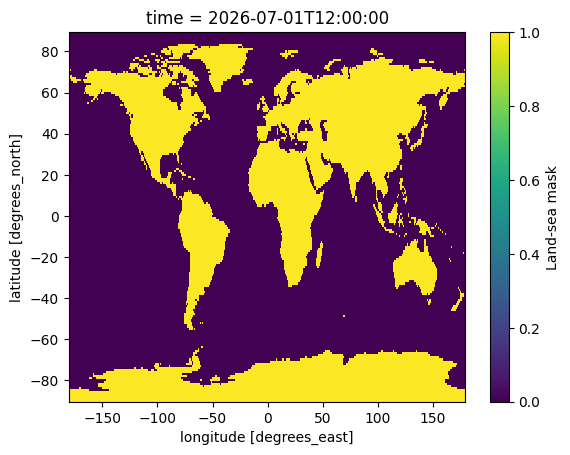

In [12]:
climatology_data.land_sea_mask.plot()

In [13]:
qc_sea = do_maritime_check(
    lat=data.lat,
    lon=data.lon,
    sea_land_mask=climatology_data.land_sea_mask,
    sea_flag=0,
)
pd.DataFrame({"location": data.location, "lat": data.lat, "lon": data.lon, "qc_sea": qc_sea})

,location,lat,lon,qc_sea
0,Mediterranean Sea,36.0,18.0,0
1,North Sea,54.5,3.0,0
2,South Pacific Ocean,-140.0,-15.0,1
3,"Paris, France",48.9,2.3,1
4,"Tokyo, Japan",35.7,139.7,1
5,"Sydney, Australia",-33.9,151.2,1
6,Gulf of Mexico,25.0,-90.0,0
7,Equatorial Atlantic,0.0,-30.0,0
8,Norwegian Sea,60.0,5.0,0


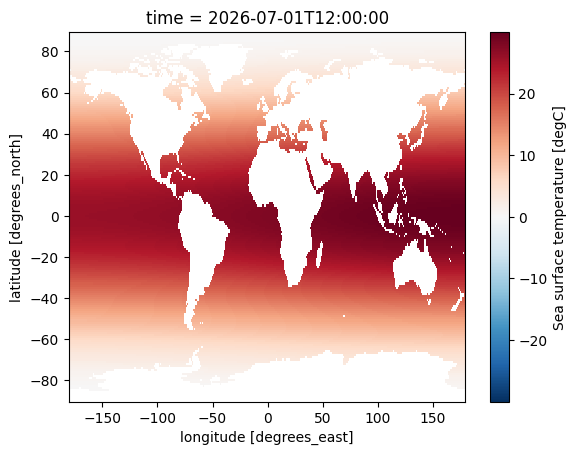

In [14]:
climatology_data.sst.plot()

In [15]:
clim_sst = get_climatological_value(climatology_data.sst, lat=data.lat, lon=data.lon)

In [16]:
qc_clim = do_climatology_check(
    value=data.sea_surface_temperature,
    climatology=climatology_data.sst,
    maximum_anomaly=5.0,
    lat=data.lat,
    lon=data.lon,
)
pd.DataFrame(
    {
        "location": data.location,
        "lat": data.lat,
        "lon": data.lon,
        "sea_surface_temperature": data.sea_surface_temperature,
        "climatology": clim_sst,
        "qc_clim": qc_clim,
    }
)

,location,lat,lon,sea_surface_temperature,climatology,qc_clim
0,Mediterranean Sea,36.0,18.0,22.8,18.579354,0
1,North Sea,54.5,3.0,13.6,9.704535,0
2,South Pacific Ocean,-140.0,-15.0,27.4,NaN,2
3,"Paris, France",48.9,2.3,NaN,NaN,2
4,"Tokyo, Japan",35.7,139.7,NaN,NaN,2
5,"Sydney, Australia",-33.9,151.2,NaN,NaN,2
6,Gulf of Mexico,25.0,-90.0,29.1,21.717314,1
7,Equatorial Atlantic,0.0,-30.0,28.3,27.482362,0
8,Norwegian Sea,60.0,5.0,8.5,7.043619,0


In [17]:
qc_dict = {
    "positional_check": {
        "func": "do_position_check",
        "names": {
            "lat": "lat",
            "lon": "lon",
        },
    },
    "datetime_check": {
        "func": "do_datetime_check",
        "names": {"date": "date"},
    },
    "hard_limit_check": {"func": "do_hard_limit_check", "names": {"value": "sea_surface_temperature"}, "arguments": {"limits": (10, 29)}},
    "maritime_check": {
        "func": "do_maritime_check",
        "names": {
            "lat": "lat",
            "lon": "lon",
        },
        "arguments": {
            "sea_land_mask": climatology_data.land_sea_mask,
            "sea_flag": 0,
        },
    },
    "climatology_check": {
        "func": "do_climatology_check",
        "names": {"value": "sea_surface_temperature"},
        "arguments": {
            "climatology": climatology_data.sst,
            "maximum_anomaly": 5.0,
            "lat": data.lat,
            "lon": data.lon,
        },
    },
    "wind_consistency_check": {
        "func": "do_wind_consistency_check",
        "names": {"wind_speed": "wind_speed", "wind_direction": "wind_direction"},
    },
}

In [18]:
qc_multi = do_multiple_individual_check(
    data,
    qc_dict,
    return_method="failed",
)
qc_multi

,positional_check,datetime_check,hard_limit_check,maritime_check,climatology_check,wind_consistency_check
0,0,0,0,0,0,0
1,0,0,0,0,0,1
2,1,3,3,3,3,3
3,0,0,2,1,3,3
4,0,0,2,1,3,3
5,0,0,2,1,3,3
6,0,2,1,3,3,3
7,0,0,0,0,0,0
8,0,0,1,3,3,3


In [19]:
qc_flag = combine_qc_results(qc_multi)
pd.DataFrame({**data, "qc_flag": qc_flag})

,location,lat,lon,date,sea_surface_temperature,wind_speed,wind_direction,qc_flag
0,Mediterranean Sea,36.0,18.0,2025-06-01 06:00:00,22.8,5.2,135,0
1,North Sea,54.5,3.0,2025-06-01 12:00:00,13.6,0.0,270,1
2,South Pacific Ocean,-140.0,-15.0,2025-06-01 18:00:00,27.4,7.8,90,1
3,"Paris, France",48.9,2.3,2025-06-02 14:30:00,NaN,3.5,45,1
4,"Tokyo, Japan",35.7,139.7,2025-06-03 08:45:00,NaN,6.2,225,1
5,"Sydney, Australia",-33.9,151.2,2025-06-03 20:10:00,NaN,8.1,160,1
6,Gulf of Mexico,25.0,-90.0,NaT,29.1,10.5,315,1
7,Equatorial Atlantic,0.0,-30.0,2025-06-04 16:20:00,28.3,5.9,110,0
8,Norwegian Sea,60.0,5.0,2025-06-05 07:50:00,8.5,14.3,290,1


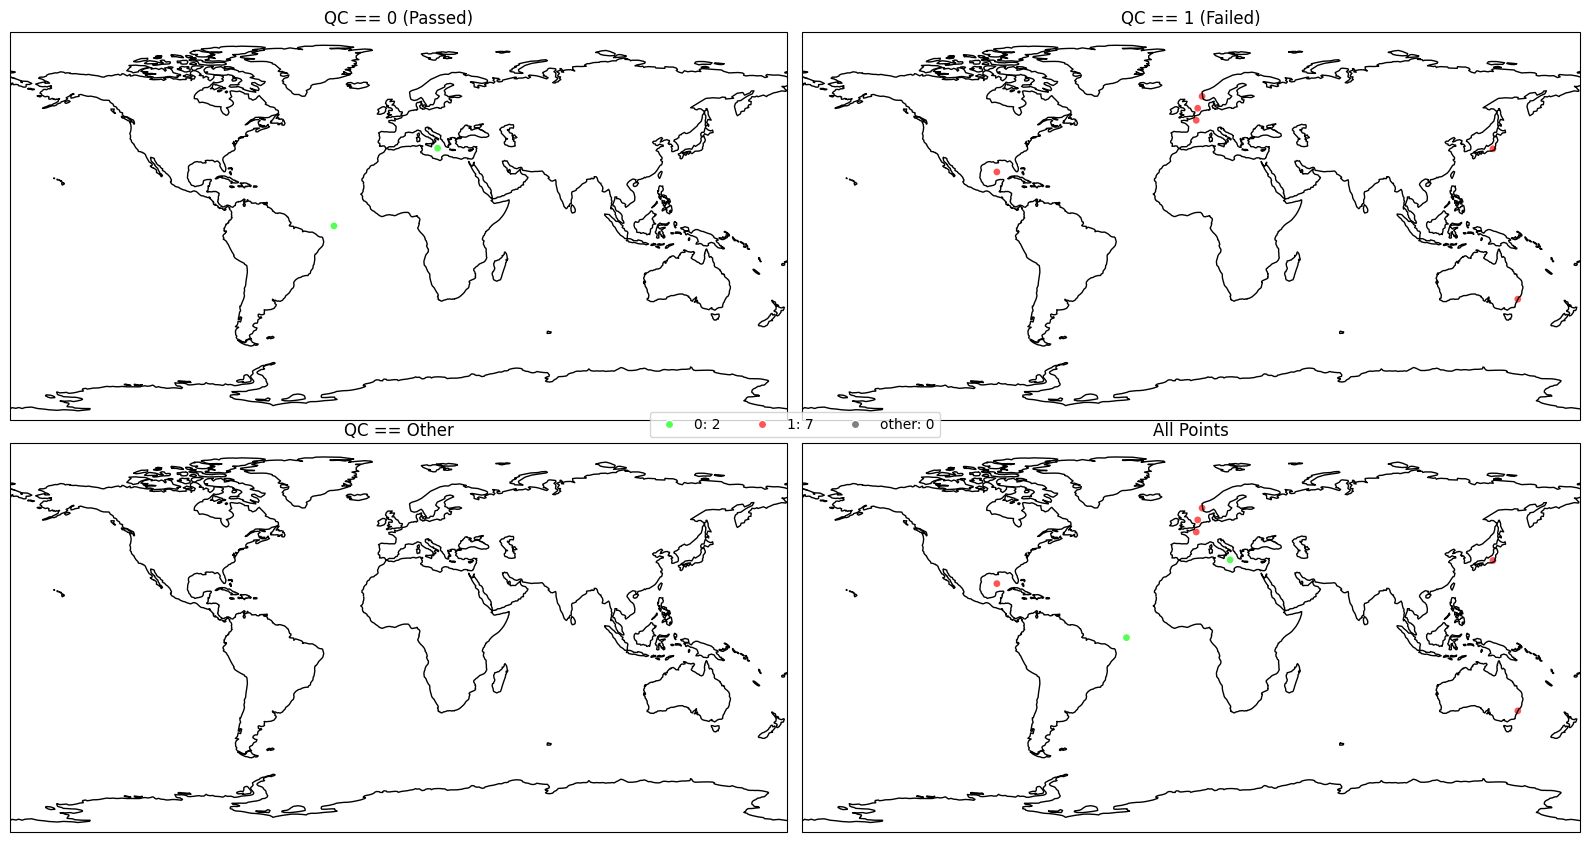

In [20]:
plot = plot_latitude_longitude(data.lat, data.lon, qc_flag, marker_size=15, add_coastlines=True)